In [1]:
import numpy as np
import pandas as pd

from statsmodels.tsa.seasonal import STL
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

In [49]:
df = pd.read_csv('monthly_crime_counts.csv')
df = df.pivot(index='month', columns='MSOA21CD', values='total_rows').fillna(0)
df.index = pd.to_datetime(df.index, format='%Y-%m')

In [50]:
df.head()

MSOA21CD,E02000001,E02000002,E02000003,E02000004,E02000005,E02000007,E02000008,E02000009,E02000010,E02000011,...,W02000418,W02000419,W02000421,W02000422,W02000423,W02000424,W02000425,W02000426,W02000427,W02000428
month,,,,,,,,,,,,,,,,,,,,,
2010-12-01,286.0,46.0,61.0,25.0,44.0,51.0,61.0,63.0,42.0,34.0,...,32.0,63.0,22.0,34.0,69.0,17.0,19.0,50.0,46.0,24.0
2011-01-01,279.0,57.0,75.0,31.0,45.0,54.0,82.0,67.0,64.0,36.0,...,27.0,50.0,21.0,36.0,76.0,27.0,15.0,55.0,64.0,17.0
2011-02-01,301.0,41.0,70.0,35.0,48.0,55.0,61.0,63.0,52.0,30.0,...,31.0,52.0,17.0,37.0,74.0,24.0,25.0,54.0,59.0,21.0
2011-03-01,300.0,57.0,72.0,29.0,51.0,51.0,70.0,75.0,60.0,47.0,...,37.0,52.0,21.0,44.0,77.0,19.0,25.0,66.0,62.0,31.0
2011-04-01,282.0,60.0,75.0,27.0,64.0,69.0,90.0,61.0,58.0,34.0,...,37.0,62.0,25.0,40.0,73.0,22.0,24.0,42.0,68.0,28.0


<Axes: xlabel='month'>

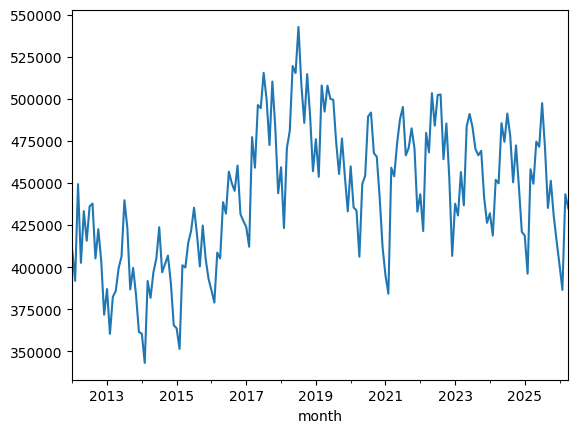

In [52]:
df.sum(axis=1).plot()

<Axes: xlabel='month'>

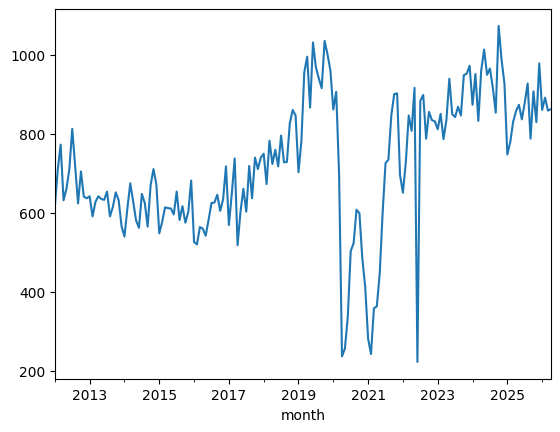

In [53]:
df['E02000001'].plot()

In [16]:
def extract_seasonal_profiles(df, period=12):
    """
    Extract normalized seasonal patterns from multiple time series.
    """

    seasonal_profiles = {}

    for col in df.columns:

        series = df[col].dropna()

        # STL decomposition
        stl = STL(series, period=period, robust=True)
        result = stl.fit()

        seasonal = result.seasonal

        # Average seasonal value by month/season index
        profile = (
            seasonal
            .groupby(series.index.month)
            .mean()
        )

        # Ensure months 1-12 exist
        profile = profile.reindex(range(1, period + 1))

        # Normalize so only shape remains
        profile = (
            profile - profile.mean()
        ) / profile.std()

        seasonal_profiles[col] = profile.values


    seasonal_df = pd.DataFrame(
        seasonal_profiles,
        index=range(1, period + 1)
    ).T

    seasonal_df.columns = [
        f"season_{i}" for i in range(1, period+1)
    ]

    return seasonal_df

In [17]:
def cluster_seasonality(
        seasonal_df,
        n_clusters=3
):

    """
    Cluster series based on seasonal shape.
    """

    X = seasonal_df.values

    model = KMeans(
        n_clusters=n_clusters,
        random_state=0,
        n_init=20
    )

    labels = model.fit_predict(X)

    result = seasonal_df.copy()
    result["cluster"] = labels

    return result, model

In [18]:
def plot_clusters(clustered_df):
    """
    Plot average seasonal pattern per cluster.
    """

    months = np.arange(1, 13)

    plt.figure(figsize=(10,6))

    for cluster, group in clustered_df.groupby("cluster"):

        mean_pattern = (
            group.drop(columns="cluster")
            .mean()
        )

        plt.plot(
            months,
            mean_pattern,
            marker="o",
            label=f"Cluster {cluster}"
        )

    plt.xticks(
        months,
        [
            "Jan","Feb","Mar","Apr",
            "May","Jun","Jul","Aug",
            "Sep","Oct","Nov","Dec"
        ]
    )

    plt.xlabel("Month")
    plt.ylabel("Normalized seasonal effect")

    plt.title(
        "Seasonal clusters"
    )

    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
seasonal_profiles = extract_seasonal_profiles(
    df,
    period=12
)

In [28]:
seasonal_profiles = seasonal_profiles.dropna()

In [46]:
inertias = []
for n_clusters in range(3, 20):
    clusters, model = cluster_seasonality(
        seasonal_profiles,
        n_clusters=n_clusters
    )
    print(f'Number of clusters: {n_clusters}, inertia: {model.inertia_}')
    inertias.append(model.inertia_)

Number of clusters: 3, inertia: 61829.32370380541
Number of clusters: 4, inertia: 59056.14071952673
Number of clusters: 5, inertia: 56962.90567617753
Number of clusters: 6, inertia: 55189.999501897095
Number of clusters: 7, inertia: 53768.47121563688
Number of clusters: 8, inertia: 52508.44993650385
Number of clusters: 9, inertia: 51313.62413622056
Number of clusters: 10, inertia: 50260.57742533606
Number of clusters: 11, inertia: 49370.261069626235
Number of clusters: 12, inertia: 48551.7159493927
Number of clusters: 13, inertia: 47774.57999143028
Number of clusters: 14, inertia: 47026.38015383524
Number of clusters: 15, inertia: 46359.61405764707
Number of clusters: 16, inertia: 45776.416228669346
Number of clusters: 17, inertia: 45212.865687594516
Number of clusters: 18, inertia: 44766.94547530063
Number of clusters: 19, inertia: 44282.16248744658


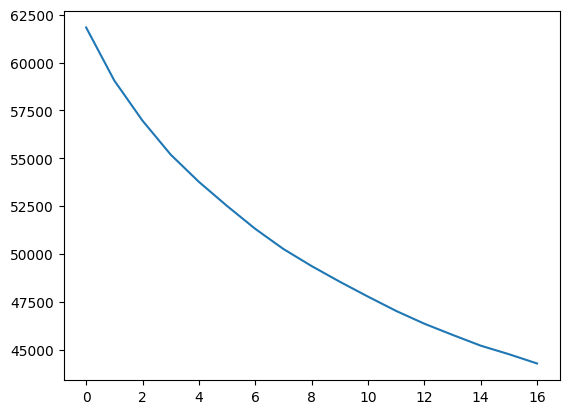

In [47]:
plt.plot(inertias)

In [39]:
clusters.loc['E02000977', :]

season_1     0.322212
season_2     0.281503
season_3     0.193321
season_4    -0.806007
season_5    -0.804088
season_6    -0.638840
season_7    -0.386172
season_8    -0.908953
season_9    -1.049185
season_10    0.058524
season_11    1.796173
season_12    1.941511
cluster      2.000000
Name: E02000977, dtype: float64

In [40]:
clusters[clusters['cluster'] == 0]

,season_1,season_2,season_3,season_4,season_5,season_6,season_7,season_8,season_9,season_10,season_11,season_12,cluster
E02000005,0.266248,-1.058796,1.053947,-0.885428,-0.323060,2.261537,-0.142029,-0.051514,0.645670,-1.488265,-0.117005,-0.161305,0
E02000009,0.741385,-0.571129,1.084806,-2.127775,0.490901,-0.982071,1.235463,0.645004,0.776600,-0.696372,-0.243862,-0.352951,0
E02000011,-0.156437,-1.374416,1.695596,0.187490,1.692045,-0.002377,-0.403596,-0.872878,0.359424,-0.790492,-1.055583,0.721225,0
E02000014,-0.812839,-1.176092,1.655698,-0.561100,0.185037,1.330554,1.056052,-0.372216,-0.114211,0.365672,-1.639478,0.082922,0
E02000019,-0.496503,-0.124726,0.504305,-1.233194,2.666650,0.796634,-0.889629,-0.223846,-0.072574,-0.325559,-0.505043,-0.096515,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
W02000397,-0.284112,-0.696698,2.072257,-1.661308,-1.198970,0.933677,-0.353832,0.426660,0.411767,0.158259,0.620597,-0.428297,0
W02000399,-0.319061,0.317801,1.976858,-1.517611,-1.325181,-0.999422,0.259646,0.896508,0.333403,0.792492,0.051614,-0.467048,0
W02000412,-1.182687,0.081357,0.872512,0.438103,0.601096,0.052994,-1.203273,1.400675,0.143388,0.068024,-2.056151,0.783963,0
W02000427,1.028005,-1.058334,1.410733,-0.726353,-0.952033,-0.856910,-0.312662,2.092244,-0.122416,-0.412256,-0.060491,-0.029528,0


In [41]:
clusters['cluster'].value_counts()

cluster
3    2088
1    1981
2    1582
0    1579
Name: count, dtype: int64

E02000001    17
E02000002    15
E02000003    12
E02000004    11
E02000005    15
             ..
W02000424     5
W02000425    15
W02000426    17
W02000427     0
W02000428    18
Name: cluster, Length: 7230, dtype: int32


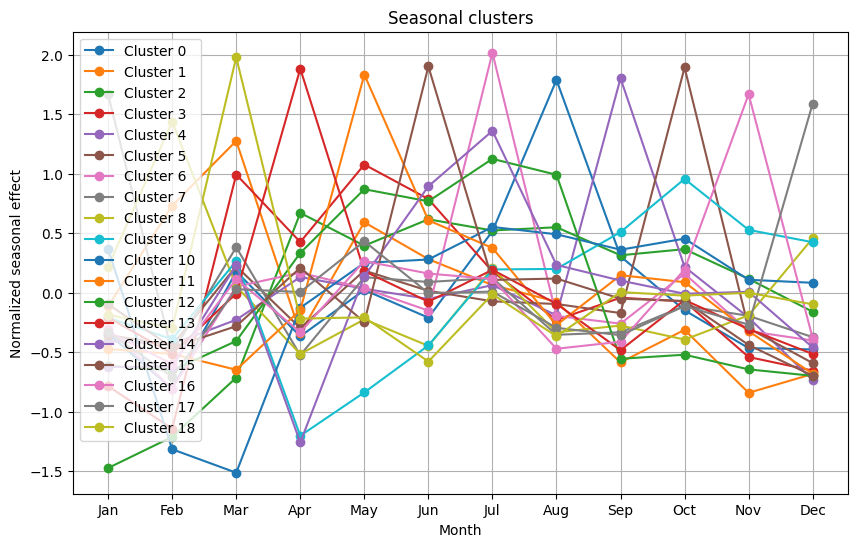

In [48]:
print(clusters["cluster"])


plot_clusters(clusters)

In [25]:
seasonal_profiles[seasonal_profiles.isna().any(axis=1)]

,season_1,season_2,season_3,season_4,season_5,season_6,season_7,season_8,season_9,season_10,season_11,season_12
E02001015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
E02001089,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
E02001163,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
E02001187,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
E02001192,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
E02001263,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
